In [1]:
from prepare_time_boroughs import prepare_yearly_boroughs, prepare_quarterly_boroughs, prepare_monthly_boroughs
from sarima_forecast import sarima_forecast, bayesian_ridge_forecast, plot_borough_forecasts
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

In [2]:
df_year = prepare_yearly_boroughs()
df_quarter = prepare_quarterly_boroughs()
df_month = prepare_monthly_boroughs()

PREPARING YEARLY DATA...
COMPLETE
PREPARING QUARTERLY DATA...
COMPLETE
PREPARING MONTHLY DATA...
COMPLETE


5 year forecast for yearly datapoints per borough

In [3]:
df_month_forecast = sarima_forecast(df_month, 72, 60)
df_quarter_forecast = sarima_forecast(df_quarter, 20, 20)

In [4]:
df_bayesian_year_forecast = bayesian_ridge_forecast(df_year, 6, 5)
df_bayesian_quarter_forecast = bayesian_ridge_forecast(df_quarter, 20, 20)
df_bayesian_month_forecast = bayesian_ridge_forecast(df_month, 72, 60)

In [5]:
df_year_covid = prepare_yearly_boroughs(ADJUST_COVID=True)
df_quarter_covid = prepare_quarterly_boroughs(ADJUST_COVID=True)
df_month_covid = prepare_monthly_boroughs(ADJUST_COVID=True)

PREPARING YEARLY DATA...
COMPLETE
PREPARING QUARTERLY DATA...
COMPLETE
PREPARING MONTHLY DATA...
COMPLETE


In [6]:
df_month_covid_forecast = sarima_forecast(df_month_covid, 72, 60)
df_quarter_covid_forecast = sarima_forecast(df_quarter_covid, 20, 20)

df_bayesian_year_covid_forecast = bayesian_ridge_forecast(df_year_covid, 6, 5)
df_bayesian_quarter_covid_forecast = bayesian_ridge_forecast(df_quarter_covid, 20, 20)
df_bayesian_month_covid_forecast = bayesian_ridge_forecast(df_month_covid, 72, 60)

In [7]:
print("------------------------------")
print("----- NON COVID ADJUSTED -----")
print("------------------------------")
print("SARIMA")
print("monthly average mape:", df_month_forecast['mape'].mean())
print("quarterly average mape:", df_quarter_forecast['mape'].mean())
print('\n')
print("BAYESIAN RIDGE REGRESSION")
print("monthly average mape:", df_bayesian_month_forecast['mape'].mean())
print("quarterly average mape:", df_bayesian_quarter_forecast['mape'].mean())
print("yearly average mape:", df_bayesian_year_forecast['mape'].mean())
print("\n\n")

print("------------------------------")
print("------- COVID ADJUSTED -------")
print("------------------------------")
print("SARIMA")
print("monthly average mape:", df_month_covid_forecast['mape'].mean())
print("quarterly average mape:", df_quarter_covid_forecast['mape'].mean())
print('\n')

print("BAYESIAN RIDGE REGRESSION")
print("monthly average mape:", df_bayesian_month_covid_forecast['mape'].mean())
print("quarterly average mape:", df_bayesian_quarter_covid_forecast['mape'].mean())
print("yearly average mape:", df_bayesian_year_covid_forecast['mape'].mean())

------------------------------
----- NON COVID ADJUSTED -----
------------------------------
SARIMA
monthly average mape: 26.574346564111107
quarterly average mape: 23.1485024339256


BAYESIAN RIDGE REGRESSION
monthly average mape: 23.437922907926193
quarterly average mape: 15.98986376706431
yearly average mape: 12.16117208908418



------------------------------
------- COVID ADJUSTED -------
------------------------------
SARIMA
monthly average mape: 27.875139908795703
quarterly average mape: 19.710654628934645


BAYESIAN RIDGE REGRESSION
monthly average mape: 24.22513122989458
quarterly average mape: 15.5676669824019
yearly average mape: 9.774876086818464


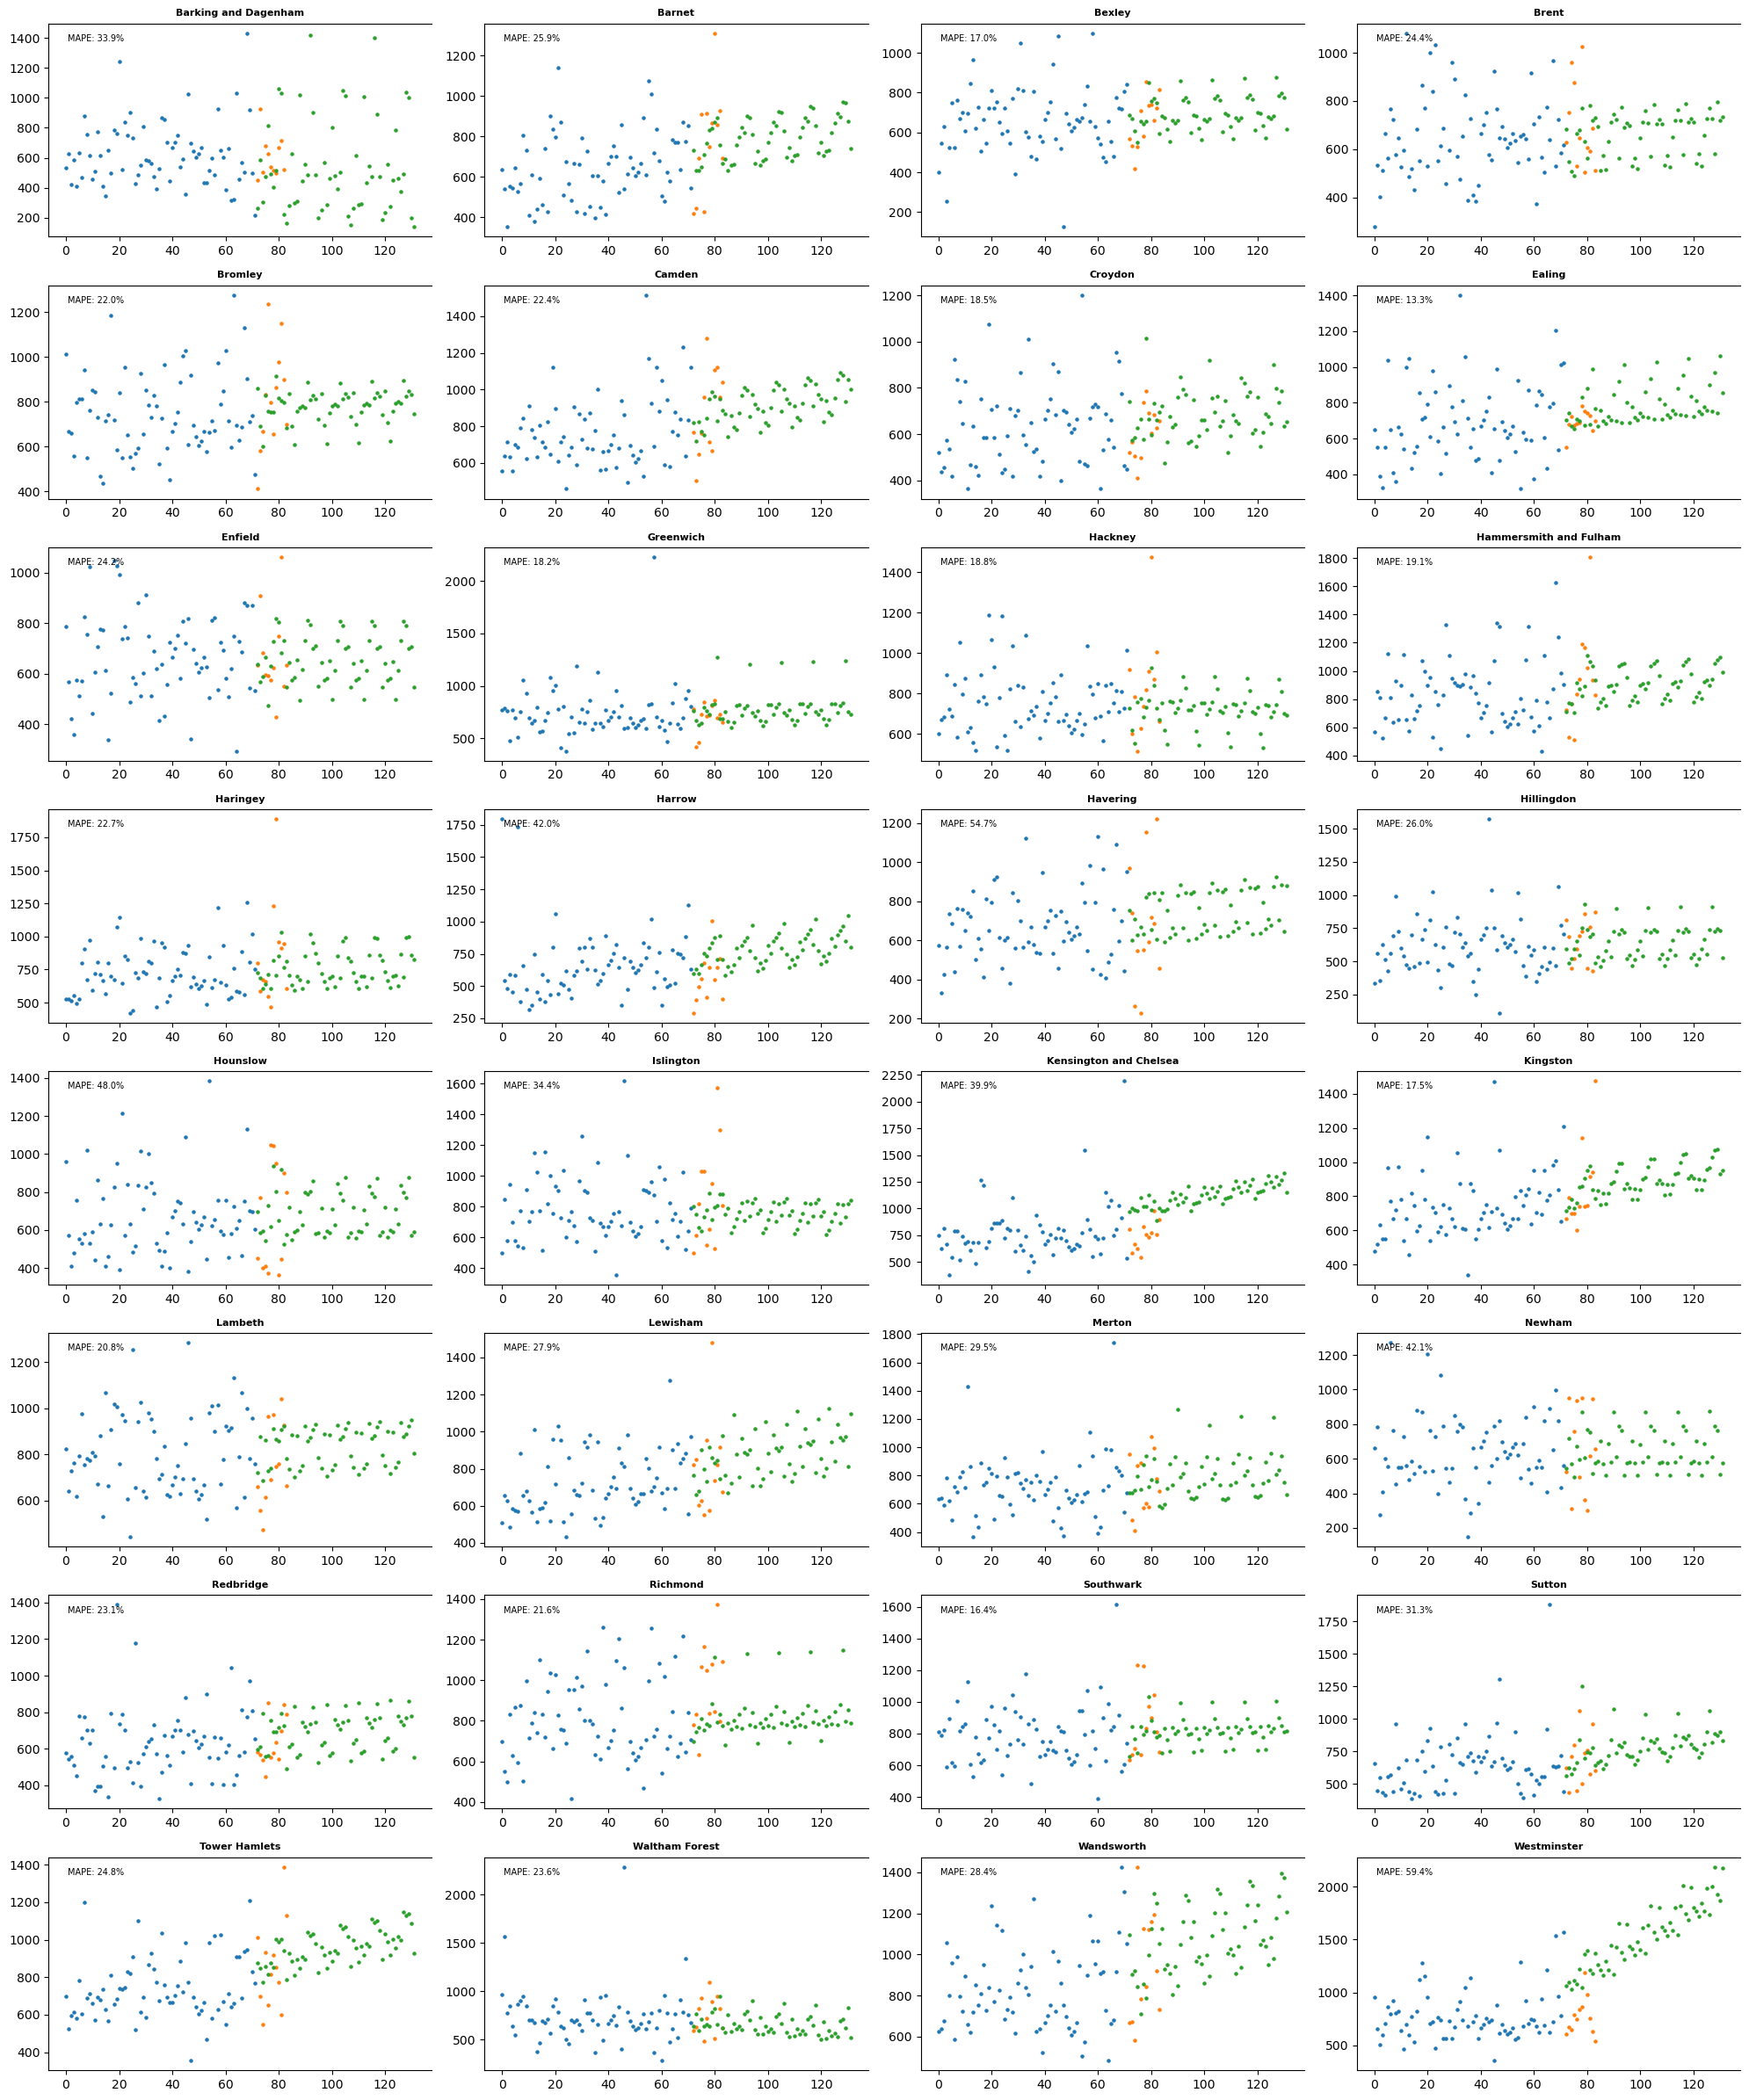

In [8]:
plot_borough_forecasts(df_month_covid_forecast, 72)

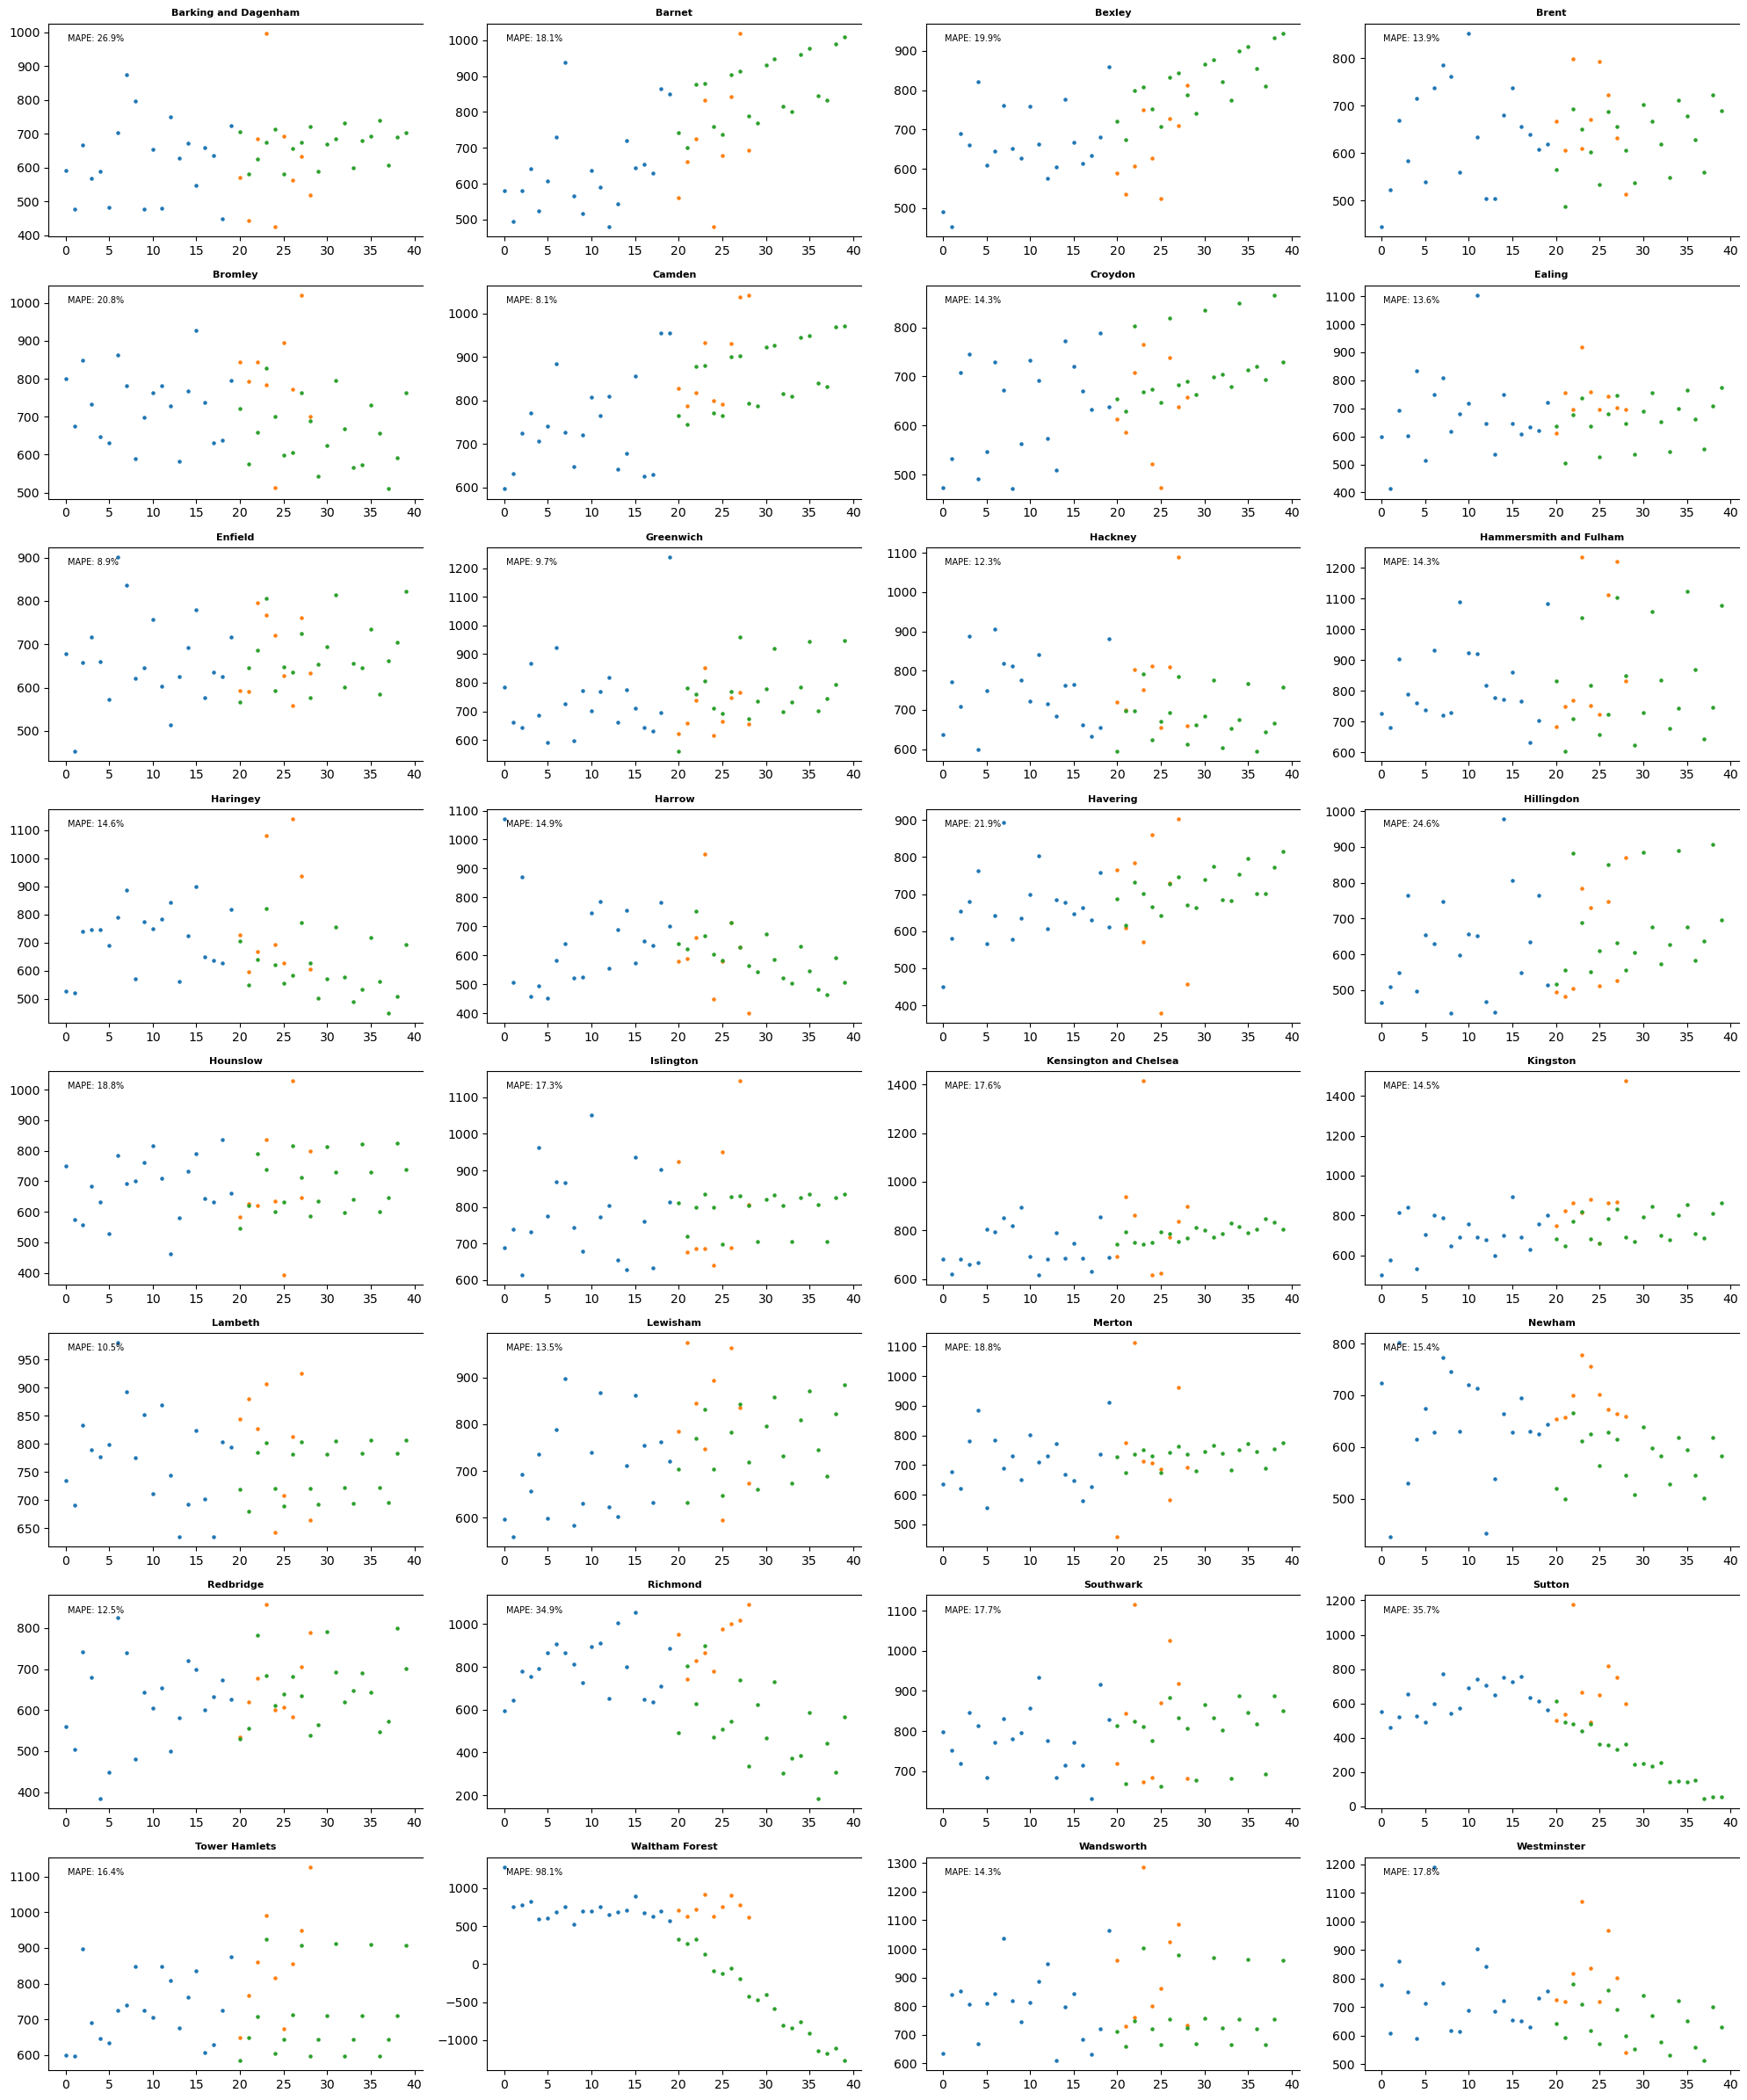

In [9]:
plot_borough_forecasts(df_quarter_covid_forecast, 20)